We check:
1. The Dataset loads the splits CSV and split sizes match what 02_split.ipynb produced (train=7009, val=1503, test=1503)
2. Individual samples return a correct (image, integer label) pair
3. Random images visually match their class labels
4. A DataLoader batch with transforms produces the expected tensor shape
5. Inverse-frequency class weights are reasonable (rare classes weighted higher)

## Setup

Add the project root to `sys.path` so the notebook can import from `src/`, then verify that the splits CSV and image folder exist.

In [2]:
import sys
from pathlib import Path

# Add the project root to Python's import path so we can do `from src.dataset import ...`
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Now we can import our own code
from src.dataset import ISICDataset, CLASS_NAMES, LABEL_TO_IDX, get_class_weights

# Paths
SPLITS_CSV  = PROJECT_ROOT / "data/processed/splits.csv"
IMAGES_DIR  = PROJECT_ROOT / "data/raw/ISIC2018_Task3_Training_Input"

print("splits.csv exists:", SPLITS_CSV.exists())
print("images_dir exists:", IMAGES_DIR.exists())
print("Class names:", CLASS_NAMES)
print("Label → idx map:", LABEL_TO_IDX)

splits.csv exists: True
images_dir exists: True
Class names: ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
Label → idx map: {'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}


In [3]:
# Create one Dataset per split, with no transforms — returns raw PIL images
train_ds = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='train', transform=None)
val_ds   = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='val',   transform=None)
test_ds  = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='test',  transform=None)

print(f"Train: {len(train_ds)} samples")
print(f"Val:   {len(val_ds)} samples")
print(f"Test:  {len(test_ds)} samples")
print(f"Total: {len(train_ds) + len(val_ds) + len(test_ds)} samples")

# Sanity: should match what 02_split.ipynb produced
assert len(train_ds) == 7009, "Train size mismatch!"
assert len(val_ds)   == 1503, "Val size mismatch!"
assert len(test_ds)  == 1503, "Test size mismatch!"
print("\n Sizes match 02_split.ipynb output")

Train: 7009 samples
Val:   1503 samples
Test:  1503 samples
Total: 10015 samples

 Sizes match 02_split.ipynb output


## Check 1 — Dataset loads and split sizes are correct

We build one Dataset object for each split (train, val, test) without any transforms, so we get raw PIL images out. Then we check that the number of samples in each split is exactly what notebook 02 produced: 7009 / 1503 / 1503.

## Check 2 — A single sample

Pull one item from the train Dataset and verify it returns `(PIL_image, integer_label)`.

In [4]:
# Grab one sample
img, label = train_ds[0]

print(f"Image type:   {type(img).__name__}")
print(f"Image size:   {img.size}  (width × height)")
print(f"Image mode:   {img.mode}")
print(f"Label (int):  {label}")
print(f"Label (name): {CLASS_NAMES[label]}")

# Sanity checks
assert img.mode == 'RGB', f"Expected RGB image, got {img.mode}"
assert isinstance(label, int), f"Expected int label, got {type(label)}"
assert 0 <= label < 7, f"Label {label} out of range"
print("\n Single sample looks correct")

Image type:   Image
Image size:   (600, 450)  (width × height)
Image mode:   RGB
Label (int):  1
Label (name): NV

 Single sample looks correct


## Check 3 — Visualize random samples

Show 6 random training images with their class names. This is the *real* test —
if the labels look wrong (e.g., a clearly benign mole labeled MEL), there's a bug
in either the splits CSV or the Dataset class.

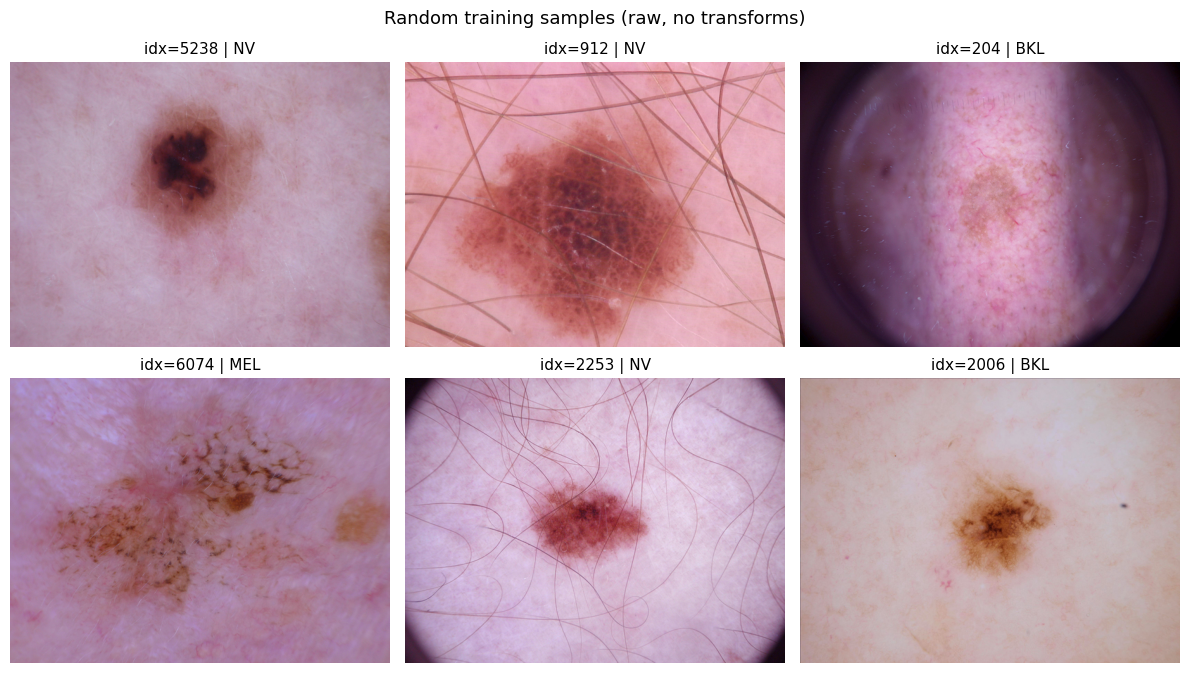

In [5]:
import random
import matplotlib.pyplot as plt

random.seed(42)
indices = random.sample(range(len(train_ds)), 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, idx in zip(axes.flat, indices):
    img, label = train_ds[idx]
    ax.imshow(img)
    ax.set_title(f"idx={idx} | {CLASS_NAMES[label]}", fontsize=11)
    ax.axis('off')

plt.suptitle("Random training samples (raw, no transforms)", fontsize=13)
plt.tight_layout()
plt.show()

The images look right — they're clearly skin lesions, and each one matches its class label (NV samples look like normal moles, BKL ones look like flat scaly patches, etc.). If there was a bug shuffling the labels or reading the wrong file, we'd see obvious mismatches here. Looks good.

## Check 4 — DataLoader batch with transforms

This is what training will actually use: images resized to 224×224, normalized
with ImageNet stats, and wrapped in a DataLoader for batching.

Expected batch shape: `[batch_size, 3, 224, 224]` for images, `[batch_size]` for labels.

In [6]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

# Standard preprocessing for pretrained ImageNet models (ResNet, EfficientNet, etc.)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Recreate train dataset with transforms applied
train_ds_t = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='train', transform=train_transform)

# DataLoader
train_loader = DataLoader(train_ds_t, batch_size=16, shuffle=True, num_workers=0)

# Fetch one batch
images, labels = next(iter(train_loader))

print(f"Images shape: {images.shape}      (expect [16, 3, 224, 224])")
print(f"Images dtype: {images.dtype}")
print(f"Pixel range:  [{images.min():.3f}, {images.max():.3f}]  (after ImageNet norm, ~[-2.1, 2.6])")
print(f"Labels shape: {labels.shape}              (expect [16])")
print(f"Labels dtype: {labels.dtype}")
print(f"Sample labels: {labels.tolist()}")

# Sanity checks
assert images.shape == (16, 3, 224, 224), f"Bad image shape: {images.shape}"
assert labels.shape == (16,), f"Bad label shape: {labels.shape}"
assert labels.dtype == torch.long, f"Labels must be long (CrossEntropyLoss requirement), got {labels.dtype}"
print("\n DataLoader produces correctly shaped batches")

Images shape: torch.Size([16, 3, 224, 224])      (expect [16, 3, 224, 224])
Images dtype: torch.float32
Pixel range:  [-2.118, 2.640]  (after ImageNet norm, ~[-2.1, 2.6])
Labels shape: torch.Size([16])              (expect [16])
Labels dtype: torch.int64
Sample labels: [1, 1, 1, 4, 1, 1, 4, 4, 1, 4, 4, 1, 1, 3, 1, 1]

 DataLoader produces correctly shaped batches


## Check 5 — Class weights for imbalance

Rare classes should get **higher** weight, common classes lower weight.
With ~67% of training data being NV, we expect NV weight near 0.2 and DF weight near 12+.

In [10]:
weights = get_class_weights(SPLITS_CSV, split='train')

print("Class weights (higher = rarer class):")
print("-" * 35)
for name, w in zip(CLASS_NAMES, weights.tolist()):
    print(f"  {name:6s} → {w:6.3f}")
print(f"\nSum of weights: {weights.sum():.2f}")
print(f"Mean weight:    {weights.mean():.2f}")

# Sanity checks
nv_idx = LABEL_TO_IDX['NV']
df_idx = LABEL_TO_IDX['DF']
assert weights[nv_idx] < weights[df_idx], "NV (common) should have LOWER weight than DF (rare)"
assert weights[nv_idx] < 1.0, "NV weight should be < 1"
assert weights[df_idx] > 1.0, "DF weight should be > 1"
print("\n")

Class weights (higher = rarer class):
-----------------------------------
  MEL    →  1.285
  NV     →  0.213
  BCC    →  2.781
  AKIEC  →  4.372
  BKL    →  1.302
  DF     → 12.516
  VASC   → 10.114

Sum of weights: 32.58
Mean weight:    4.65




## Wrap-up

DF gets a weight of about 12.5 and NV gets about 0.2 — so a wrong prediction on a DF image will hurt the loss roughly 60× more than a wrong prediction on an NV image. That's the whole point: force the model to actually care about the rare classes. We'll feed this tensor into `nn.CrossEntropyLoss(weight=...)` in the baseline training notebook coming up next.